### Librerias

In [1]:
# Cargar de archivos de datos y librerías necesarias
import sys
sys.path.append("..")
from src.utils.constants import AGLOMERADOS_NOMBRES
from src.utils.constants import INDIVIDUOS_PROCESSED_DIR, HOGARES_PROCESSED_DIR
from src.utils.constants import COORDENADAS_AGLOMERADOS
# Librerías para el análisis de datos
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.express as px
import pandas as pd
import streamlit as st


In [2]:
# Cargar datos procesados (asegúrate de tener bien la ruta)
df_individuos =pd.read_csv(INDIVIDUOS_PROCESSED_DIR, sep=";", encoding="utf-8",low_memory=False)

###  Creo mis dataset filtrado 

In [3]:
#Filtro mis columnas de interés
columnas_emp = ['AGLOMERADO', 'ANO4', 'TRIMESTRE', 'NIVEL_ED_str', 'CONDICION_LABORAL', 'PONDERA','PP04A']
df_empleo = df_individuos[columnas_emp].copy()


In [4]:
# Armo mis variables para filtrar el dateset
anio_trim = df_empleo.groupby('ANO4')['TRIMESTRE'].unique().apply(list).to_dict()
anio_trim

{2020: [1], 2021: [1], 2022: [1, 2, 3], 2023: [2]}

### 1.5.1 Para las personas desocupadas, informar la cantidad de ellas según sus estudios alcanzados. Se debe informar para un año y trimestre elegido por el usuario.

In [5]:
st.title("Análisis de Desocupados por Nivel Educativo")

# Configuro el selector de año y trimestre
anio = st.selectbox("Seleccioná un año",anio_trim.keys())
trimestre = st.selectbox("Seleccioná un año", anio_trim[anio])

# Filtro por año, trimestre y condición laboral

df_filtrado= df_empleo[(df_empleo['ANO4'] == anio) & (df_empleo['TRIMESTRE'] == trimestre) & (df_empleo['CONDICION_LABORAL'] == 'Desocupado')]

# Agrupar por nivel educativo
df_educacion_desocupado = df_filtrado.groupby('NIVEL_ED_str')['PONDERA'].sum().sort_values(ascending=False)
df_educacion_desocupado

2025-06-01 03:47:03.853 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:08.266 
  command:

    streamlit run C:\Users\PC\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-06-01 03:47:08.270 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:08.275 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:08.280 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:08.286 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:08.300 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:08.302 Session

NIVEL_ED_str
Secundario completo         430036
Superior o universitario    417689
Secundario incompleto       330191
Primario completo           166777
Primario incompleto          46441
Sin Información               2984
Name: PONDERA, dtype: int64

#### Armo gráfico

Gráfico de barras


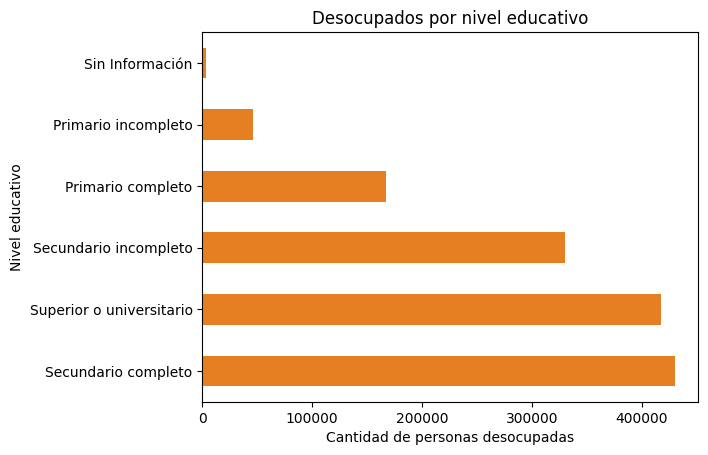

In [6]:
# Subtítulo (opcional en Jupyter, si querés podés imprimirlo)
print("Gráfico de barras")

# Crear la figura y el eje
fig, ax = plt.subplots()

# Dibujar el gráfico de barras horizontal
df_educacion_desocupado.plot(kind='barh', ax=ax, color="#E67E22")

# Etiquetas
ax.set_xlabel("Cantidad de personas desocupadas")
ax.set_ylabel("Nivel educativo")
ax.set_title("Desocupados por nivel educativo")

# Mostrar el gráfico
plt.show()

In [7]:
# Streamlit para mostrar el gráfico
st.subheader("Tabla de cantidad de desocupados por nivel educativo")
st.dataframe(df_educacion_desocupado.rename("Cantidad de Personas").to_frame())

2025-06-01 03:47:09.079 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:09.080 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:09.199 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:09.201 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

### 1.5.2 Informar la evolución del desempleo(tasa de desempleo) a lo largo del tiempo. Se debe poder filtrar por aglomerado y en caso de no elegir ninguno se debe calcular para todo el país. La tasa de desempleo es el cociente de personas desocupadas y la suma de personas desocupadas más ocupadas multiplicado por 100.

FUNCIONES BACK

In [8]:
# Funciones
def mapear_nombres_aglomerados(df) :
    print(df[['AGLOMERADO']].head())
    print(type(AGLOMERADOS_NOMBRES))
    print(type(df['AGLOMERADO']))
    df['AGLOMERADO_NOMBRE'] = df['AGLOMERADO'].map(AGLOMERADOS_NOMBRES)
    print(type(AGLOMERADOS_NOMBRES))

    return df

import pandas as pd

def calcular_tasa_emp_desemp(df, condicion=None, agrupacion=['ANO4', 'TRIMESTRE']):
    """
    Calcula la tasa de empleo y/o desempleo por las columnas que se pasen en 'agrupacion'.

    Parámetros:
    - df: DataFrame con las columnas 'CONDICION_LABORAL', 'PONDERA' y las que se agrupen.
    - condicion: 'Desocupado', 'Ocupado' o None (para ambas tasas).
    - agrupacion: lista de columnas para agrupar dinámicamente.

    Devuelve:
    - DataFrame con la(s) tasa(s) calculada(s) por grupo.
    """

    # Me aseguro que se una lista
    if isinstance(agrupacion, str):
        agrupacion = [agrupacion]

    # Agrupo y  calculo  sumatorias ponderadas por tipo de empleo
    df_tasa = df.groupby(agrupacion).apply(lambda g: pd.Series({
        'Desocupado': g[g['CONDICION_LABORAL'] == 'Desocupado']['PONDERA'].sum(),
        'Ocupado': g[g['CONDICION_LABORAL'].str.contains('Ocupado', na=False)]['PONDERA'].sum()
    })).reset_index()

    # Del agrupado calculo el total
    total = df_tasa['Desocupado'] + df_tasa['Ocupado']

    # Calcular tasas
    df_tasa['Tasa de Desempleo'] = round((df_tasa['Desocupado'] / total) * 100, 2)
    df_tasa['Tasa de Empleo'] = round((df_tasa['Ocupado'] / total) * 100, 2)

    # Armar columnas a devolver según parámetro
    if condicion == 'Desocupado':
        columnas = agrupacion + ['Tasa de Desempleo']
    elif condicion == 'Ocupado':
        columnas = agrupacion + ['Tasa de Empleo']
    elif condicion ==None or 'ambas':
        columnas = agrupacion + ['Tasa de Desempleo', 'Tasa de Empleo']

    return df_tasa[columnas].sort_values(by=agrupacion)


def listar(df, columna):
    """Devuelve una lista de valores únicos de una columna del DataFrame."""
    return df[columna].unique().tolist()

def agregar_columna_fecha(df):
    """
    Agrega una columna 'Fecha' combinando ANO4 y TRIMESTRE para graficar series temporales.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'ANO4' y 'TRIMESTRE'.

    Returns:
        pd.DataFrame: DataFrame con la columna 'Fecha' como datetime.
    """
    df = df.copy()
    df['Fecha'] = df['ANO4'].astype(str) + '-T' + df['TRIMESTRE'].astype(str)
    return df

def graficar_tasa(df, columna_tasa, titulo):
    """
    Grafica la evolución temporal de una tasa usando Plotly.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'Fecha' y una tasa.
        columna_tasa (str): Nombre de la columna que contiene la tasa a graficar.
        titulo (str): Título del gráfico.
    """
    fig = px.line(df, x='Fecha', y=columna_tasa, title=titulo)
    fig.show()
    st.plotly_chart(fig)


PARTE EN STREAMLIT

In [9]:
# Título
st.title("Evolución de la tasa de desempleo")

#Listar Aglomerados
df_empleo=mapear_nombres_aglomerados(df_empleo)


aglomerados = listar(df_empleo, 'AGLOMERADO_NOMBRE')

# Mostrar el multiselect con los nombres de los aglomerados
seleccionados = st.multiselect("Seleccioná uno o más aglomerados (opcional)",options=aglomerados,default=aglomerados)

# Filtrar los datos solo con condiciones laborales válidas
df_filtrados = df_empleo[df_empleo['AGLOMERADO_NOMBRE'].isin(seleccionados)]   

# Filtrar las condiciones laborales válidas
condicion_valida =['Ocupado autónomo', 'Ocupado dependiente', 'Desocupado']
df_filtrado = df_filtrados[df_filtrados['CONDICION_LABORAL'].isin(condicion_valida)]

# Calcular suma de ponderaciones por grupo
df_tasa_desempleo = calcular_tasa_emp_desemp(df_filtrado, condicion='Desocupado')
df_tasa_desempleo

2025-06-01 03:47:09.310 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:09.312 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:09.407 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:09.412 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:09.415 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:09.424 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:09.429 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


   AGLOMERADO
0          18
1          18
2          18
3          18
4          18
<class 'dict'>
<class 'pandas.core.series.Series'>
<class 'dict'>


C:\Users\PC\AppData\Local\Temp\ipykernel_12952\3743284477.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_tasa = df.groupby(agrupacion).apply(lambda g: pd.Series({


,ANO4,TRIMESTRE,Tasa de Desempleo
0,2020,1,10.37
1,2021,1,10.16
2,2022,1,6.97
3,2022,2,6.86
4,2022,3,7.11
5,2023,2,6.24


### 1.5.3
Informar la evolución del empleo (tasa de empleo) a lo largo del tiempo. Se debe poder
filtrar por aglomerado y en caso de no elegir ninguno se debe calcular para todo el país.
La tasa de empleo es el cociente entre personas ocupadas y la suma de personas
desocupadas más ocupadas multiplicado por 100.

PARTE EN STREAMLIT

In [10]:
# Título
st.title("Evolución de la tasa de empleo")

# Mostrar el multiselect con los nombres de los aglomerados
seleccionados = st.multiselect("Seleccioná uno o más aglomerados (opcional)",options=aglomerados,default=aglomerados)

# Filtrar los datos solo con condiciones laborales válidas
df_filtrados = df_empleo[df_empleo['AGLOMERADO_NOMBRE'].isin(seleccionados)]   

# Filtrar las condiciones laborales válidas
condicion_valida =['Ocupado autónomo', 'Ocupado dependiente', 'Desocupado']
df_filtrado = df_filtrados[df_filtrados['CONDICION_LABORAL'].isin(condicion_valida)]

# Calcular suma de ponderaciones por grupo
df_tasa_ocupado = calcular_tasa_emp_desemp(df_filtrado, condicion='Ocupado')

df_tasa_ocupado


2025-06-01 03:47:09.911 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:09.913 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:09.915 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:09.921 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:09.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:09.924 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:09.926 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
C:\Users\PC\AppData\Local\Temp\ipykernel_12952\3743284477.py:31: DeprecationWarning: DataFrameGroupBy.apply operated o

,ANO4,TRIMESTRE,Tasa de Empleo
0,2020,1,89.63
1,2021,1,89.84
2,2022,1,93.03
3,2022,2,93.14
4,2022,3,92.89
5,2023,2,93.76


In [11]:
df_tasa_ocupado=agregar_columna_fecha(df_tasa_ocupado)
graficar_tasa(df_tasa_ocupado, 'Tasa de Empleo', 'Evolución de la tasa de empleo')


2025-06-01 03:47:12.495 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:12.496 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:12.505 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-06-01 03:47:12.507 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


### 1.5.4 Informar para cada aglomerado el total de personas ocupadas, el porcentaje con empleo estatal, el porcentaje con empleo privado y el porcentaje de otro tipo. Considerar la ocupación principal

In [12]:

# 1. Mofico nombre de columna PP04A a Tipo_empleo
df_empleo.rename(columns={'PP04A': 'Tipo_empleo'}, inplace=True)

tipo_empleo_dict = {
    1: 'Estatal',
    2: 'Privado',
    3: 'Otro tipo'
}

# 2. Cambio valores de Tipo_empleo a nombres descriptivos
df_empleo['Tipo_empleo'] = df_empleo['Tipo_empleo'].map(tipo_empleo_dict)


# 3. Filtrar solo ocupados
df_ocupado = df_empleo[df_empleo['CONDICION_LABORAL'].str.contains('Ocupado', na=False)]

# 4. Calcular totales por aglomerado y tipo de empleo
tabla = df_ocupado.groupby(['AGLOMERADO_NOMBRE', 'Tipo_empleo'])['PONDERA'].sum().unstack(fill_value=0)

# 5. Calculo cada columna de porcentaje

tabla['Total_ocupados'] = tabla.sum(axis=1)

# 5. Calcular porcentajes
tabla['% Estatal'] = round((tabla['Estatal'] / tabla['Total_ocupados']) * 100, 2)
tabla['% Privado'] = round(tabla['Privado'] / tabla['Total_ocupados']* 100, 2)
tabla['% Otro tipo'] =round(tabla['Otro tipo'] / tabla['Total_ocupados']* 100, 2)

# 6. Armo mi tabla final
df_ocupados_aglomerado = tabla[['Total_ocupados', '% Estatal', '% Privado', '% Otro tipo']].reset_index()


In [13]:
df_ocupados_aglomerado

Tipo_empleo,AGLOMERADO_NOMBRE,Total_ocupados,% Estatal,% Privado,% Otro tipo
0,Bahía Blanca - Cerri,849832,17.10,80.74,2.16
1,Ciudad Autónoma de Buenos Aires,9045023,19.09,79.23,1.68
2,Comodoro Rivadavia - Rada Tilly,577643,19.40,79.64,0.95
3,Concordia,372702,21.66,77.68,0.66
4,Corrientes,956980,23.38,75.68,0.94
5,Formosa,543115,26.77,72.05,1.18
6,Gran Catamarca,568260,38.54,59.89,1.57
7,Gran Córdoba,4156741,11.46,87.07,1.47
8,Gran La Plata,2411809,29.96,69.72,0.32
9,Gran Mendoza,2903980,15.64,82.73,1.63


In [14]:

# ACA ESTABA VIENDO COMO HACERLO CON GROUPBY 
#tabla=df_ocupado.groupby(['ANO4', 'TRIMESTRE', 'Tipo_empleo'])['PONDERA'].sum().unstack(fill_value=0).reset_index()

# ACA ESTABA VIENDO COMO HACERLO CON PIVOT_TABLE
'''tabla = df_ocupado.pivot_table(
    index=['ANO4', 'TRIMESTRE'],
    columns='Tipo_empleo',
    values='PONDERA',
    aggfunc='sum',
    fill_value=0  # opcional: pone 0 donde no hay datos
).reset_index()
'''




"tabla = df_ocupado.pivot_table(\n    index=['ANO4', 'TRIMESTRE'],\n    columns='Tipo_empleo',\n    values='PONDERA',\n    aggfunc='sum',\n    fill_value=0  # opcional: pone 0 donde no hay datos\n).reset_index()\n"

### 1.5.5 

Se debe obtener por aglomerado el porcentaje de la tasa de empleo y desempleo. 

Esta información se requiere conocer para el año y trimestre más antiguo del cual se contenga información y para el año y trimestre más actual del cual se cuenta información.

A partir de dicha información se debe visualizar un mapa que por aglomerado muestre con el color de un punto/marca si el porcentaje aumentó o disminuyó. El usuario elegirá si desea
ver tasa de empleo o desempleo:

- Al elegir la tasa de empleo se deben ver puntos verdes en los aglomerados cuya tasa de empleo aumentó con el correr del tiempo. Rojo en el caso contrario.

- Al elegir la tasa de desempleo se deben ver puntos rojos en los aglomerados cuya tasa de empleo aumentó con el correr del tiempo. Verde en el caso contrario.

In [15]:
df_emp_des=calcular_tasa_emp_desemp(df_empleo, condicion=None, agrupacion=['AGLOMERADO_NOMBRE','ANO4', 'TRIMESTRE'])

df_sorted=df_emp_des.sort_values(by=['AGLOMERADO_NOMBRE','ANO4', 'TRIMESTRE'])

min_date_aglomerado = df_sorted.drop_duplicates(subset='AGLOMERADO_NOMBRE', keep='first')
max_date_aglomerado = df_sorted.drop_duplicates(subset='AGLOMERADO_NOMBRE', keep='last')

emp_des_comp=pd.merge(min_date_aglomerado,max_date_aglomerado,on='AGLOMERADO_NOMBRE',how='inner',suffixes=('_MIN', '_MAX') )

emp_des_comp = emp_des_comp[sorted(emp_des_comp.columns)]

emp_des_comp



C:\Users\PC\AppData\Local\Temp\ipykernel_12952\3743284477.py:31: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,AGLOMERADO_NOMBRE,ANO4_MAX,ANO4_MIN,TRIMESTRE_MAX,TRIMESTRE_MIN,Tasa de Desempleo_MAX,Tasa de Desempleo_MIN,Tasa de Empleo_MAX,Tasa de Empleo_MIN
0,Bahía Blanca - Cerri,2023,2020,2,1,6.05,6.97,93.95,93.03
1,Ciudad Autónoma de Buenos Aires,2023,2020,2,1,3.93,8.53,96.07,91.47
2,Comodoro Rivadavia - Rada Tilly,2023,2020,2,1,3.21,5.77,96.79,94.23
3,Concordia,2023,2020,2,1,6.77,10.51,93.23,89.49
4,Corrientes,2023,2020,2,1,4.59,4.05,95.41,95.95
5,Formosa,2023,2020,2,1,2.04,4.03,97.96,95.97
6,Gran Catamarca,2023,2020,2,1,5.01,8.58,94.99,91.42
7,Gran Córdoba,2023,2020,2,1,8.33,10.83,91.67,89.17
8,Gran La Plata,2023,2020,2,1,5.49,8.97,94.51,91.03
9,Gran Mendoza,2023,2020,2,1,5.33,9.75,94.67,90.25


In [16]:
emp_des_comp['var_tasa_Empleo'] = emp_des_comp['Tasa de Empleo_MAX'] - emp_des_comp['Tasa de Empleo_MIN']
emp_des_comp['var_tasa_Desempleo'] = emp_des_comp['Tasa de Desempleo_MAX'] - emp_des_comp['Tasa de Desempleo_MIN']

emp_des_comp = emp_des_comp[['Tasa de Empleo_MIN', 'Tasa de Empleo_MAX', 'var_tasa_Empleo',
                             'Tasa de Desempleo_MIN', 'Tasa de Desempleo_MAX', 'var_tasa_Desempleo']]

emp_des_comp

,Tasa de Empleo_MIN,Tasa de Empleo_MAX,var_tasa_Empleo,Tasa de Desempleo_MIN,Tasa de Desempleo_MAX,var_tasa_Desempleo
0,93.03,93.95,0.92,6.97,6.05,-0.92
1,91.47,96.07,4.60,8.53,3.93,-4.60
2,94.23,96.79,2.56,5.77,3.21,-2.56
3,89.49,93.23,3.74,10.51,6.77,-3.74
4,95.95,95.41,-0.54,4.05,4.59,0.54
5,95.97,97.96,1.99,4.03,2.04,-1.99
6,91.42,94.99,3.57,8.58,5.01,-3.57
7,89.17,91.67,2.50,10.83,8.33,-2.50
8,91.03,94.51,3.48,8.97,5.49,-3.48
9,90.25,94.67,4.42,9.75,5.33,-4.42


REVISO DATAFRAME DE COORDENDAS

In [26]:
df_coordendas=pd.read_json(COORDENADAS_AGLOMERADOS)
df=df_coordendas.T
df

,nombre,coordenadas
2,Gran La Plata,"[-34.9206, -57.9547]"
3,Bahía Blanca - Cerri,"[-38.719, -62.266]"
4,Gran Rosario,"[-32.9468, -60.6393]"
5,Gran Santa Fe,"[-31.6237, -60.6982]"
6,Gran Paraná,"[-31.7367, -60.523]"
7,Posadas,"[-27.3671, -55.8961]"
8,Gran Resistencia,"[-27.4512, -58.9862]"
9,Comodoro Rivadavia - Rada Tilly,"[-45.8626, -67.494]"
10,Gran Mendoza,"[-32.8895, -68.8458]"
12,Corrientes,"[-27.4678, -58.8344]"


In [32]:
import folium

# Crear un mapa centrado en Argentina
mapa = folium.Map(location=[-34.5, -58], zoom_start=5)

# Agregar marcadores
for _, row in df.iterrows():
    lat, lon = row['coordenadas']
    folium.Marker(location=[lat, lon], popup=row['nombre']).add_to(mapa)

# Mostrar el mapa
mapa
